<a href="https://colab.research.google.com/github/wan-chtvlv/spatial-coastal-ses/blob/main/A1_3_tutorial_open_buildings_spatial_analysis_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A1-3 Tutorial from Google Colab

[Open Buildings - spatial analysis examples](https://colab.research.google.com/github/google-research/google-research/blob/master/building_detection/open_buildings_spatial_analysis_examples.ipynb)

This notebook demonstrates some analysis methods with [Open Buildings](https://sites.research.google/open-buildings/) data:

* Generating heatmaps of building density and size.
* A simple analysis of accessibility to health facilities.

Example of using markdown interface with the code running in the background

In [ ]:
#@title OpenBuildings - download region polygons and points
#-------------------------------------------
# Code copied from the [Download Steps](https://colab.research.google.com/github/google-research/google-research/blob/master/building_detection/open_buildings_download_region_polygons.ipynb#scrollTo=qP6ADuzRdZTF)
# Markdown version
# ------------------------------------------
#@markdown First, select a region from either the [Natural Earth low res](https://www.naturalearthdata.com/downloads/110m-cultural-vectors/110m-admin-0-countries/) (fastest), [Natural Earth high res](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/10m-admin-0-countries/) or [World Bank high res](https://datacatalog.worldbank.org/dataset/world-bank-official-boundaries) shapefiles:
region_border_source = 'Natural Earth (Low Res 110m)'  #@param ["Natural Earth (Low Res 110m)", "Natural Earth (High Res 10m)", "World Bank (High Res 10m)"]
region = "PHL (Philippines)"  # @param ["", "ABW (Aruba)", "AGO (Angola)", "AIA (Anguilla)", "ARG (Argentina)", "ATG (Antigua and Barbuda)", "BDI (Burundi)", "BEN (Benin)", "BFA (Burkina Faso)", "BGD (Bangladesh)", "BHS (The Bahamas)", "BLM (Saint Barthelemy)", "BLZ (Belize)", "BOL (Bolivia)", "BRA (Brazil)", "BRB (Barbados)", "BRN (Brunei)", "BTN (Bhutan)", "BWA (Botswana)", "CAF (Central African Republic)", "CHL (Chile)", "CIV (Ivory Coast)", "CMR (Cameroon)", "COD (Democratic Republic of the Congo)", "COG (Republic of Congo)", "COL (Colombia)", "COM (Comoros)", "CPV (Cape Verde)", "CRI (Costa Rica)", "CUB (Cuba)", "CUW (Cura\u00e7ao)", "CYM (Cayman Islands)", "DJI (Djibouti)", "DMA (Dominica)", "DOM (Dominican Republic)", "DZA (Algeria)", "ECU (Ecuador)", "EGY (Egypt)", "ERI (Eritrea)", "ETH (Ethiopia)", "FLK (Falkland Islands)", "GAB (Gabon)", "GHA (Ghana)", "GIN (Guinea)", "GMB (Gambia)", "GNB (Guinea Bissau)", "GNQ (Equatorial Guinea)", "GRD (Grenada)", "GTM (Guatemala)", "GUY (Guyana)", "HND (Honduras)", "HTI (Haiti)", "IDN (Indonesia)", "IND (India)", "IOT (British Indian Ocean Territory)", "JAM (Jamaica)", "KEN (Kenya)", "KHM (Cambodia)", "KNA (Saint Kitts and Nevis)", "LAO (Laos)", "LBR (Liberia)", "LCA (Saint Lucia)", "LKA (Sri Lanka)", "LSO (Lesotho)", "MAF (Saint Martin)", "MDG (Madagascar)", "MDV (Maldives)", "MEX (Mexico)", "MOZ (Mozambique)", "MRT (Mauritania)", "MSR (Montserrat)", "MUS (Mauritius)", "MWI (Malawi)", "MYS (Malaysia)", "MYT (Mayotte)", "NAM (Namibia)", "NER (Niger)", "NGA (Nigeria)", "NIC (Nicaragua)", "NPL (Nepal)", "PAN (Panama)", "PER (Peru)", "PHL (Philippines)", "PRI (Puerto Rico)", "PRY (Paraguay)", "RWA (Rwanda)", "SDN (Sudan)", "SEN (Senegal)", "SGP (Singapore)", "SHN (Saint Helena)", "SLE (Sierra Leone)", "SLV (El Salvador)", "SOM (Somalia)", "STP (Sao Tome and Principe)", "SUR (Suriname)", "SWZ (Eswatini)", "SXM (Sint Maarten)", "SYC (Seychelles)", "TCA (Turks and Caicos Islands)", "TGO (Togo)", "THA (Thailand)", "TLS (East Timor)", "TTO (Trinidad and Tobago)", "TUN (Tunisia)", "TZA (United Republic of Tanzania)", "UGA (Uganda)", "URY (Uruguay)", "VCT (Saint Vincent and the Grenadines)", "VEN (Venezuela)", "VGB (British Virgin Islands)", "VIR (United States Virgin Islands)", "VNM (Vietnam)", "ZAF (South Africa)", "ZMB (Zambia)", "ZWE (Zimbabwe)"]
#@markdown **or** specify an area of interest in [WKT format](https://en.wikipedia.org/wiki/Well-known_text_representation_of_geometry) (assumes crs='EPSG:4326'); this [tool](https://arthur-e.github.io/Wicket/sandbox-gmaps3.html) might be useful.
your_own_wkt_polygon = ''  #@param {type:"string"}
#@markdown Select type of data to download here:
data_type = 'points'  #@param ["polygons", "points"]

In [ ]:


# ------------------------------------------
!sudo apt-get install swig
!pip install s2geometry geopandas

import functools
import glob
import gzip
import multiprocessing
import os
import shutil
import tempfile
from typing import List, Optional, Tuple

import geopandas as gpd
from IPython import display
import pandas as pd
import s2geometry as s2
import shapely
import tensorflow as tf
import tqdm.notebook

# ------------------------------------------
# same variables as above, but a non-markdown version
region_border_source = 'Natural Earth (Low Res 110m)'
region = 'PHL (Philippines)'
your_own_wkt_polygon = ''
data_type = 'points'

BUILDING_DOWNLOAD_PATH = ('gs://open-buildings-data/v3/'
                          f'{data_type}_s2_level_6_gzip_no_header')

# ------------------------------------------
def get_filename_and_region_dataframe(
    region_border_source: str, region: str,
    your_own_wkt_polygon: str) -> Tuple[str, gpd.geodataframe.GeoDataFrame]:
  """Returns output filename and a geopandas dataframe with one region row."""

  if your_own_wkt_polygon:
    filename = f'open_buildings_v3_{data_type}_your_own_wkt_polygon.csv.gz'
    region_df = gpd.GeoDataFrame(
        geometry=gpd.GeoSeries.from_wkt([your_own_wkt_polygon]),
        crs='EPSG:4326')
    if not isinstance(region_df.iloc[0].geometry,
                      shapely.geometry.polygon.Polygon) and not isinstance(
                          region_df.iloc[0].geometry,
                          shapely.geometry.multipolygon.MultiPolygon):
      raise ValueError("`your_own_wkt_polygon` must be a POLYGON or "
                      "MULTIPOLYGON.")
    print(f'Preparing your_own_wkt_polygon.')
    return filename, region_df

  if not region:
    raise ValueError('Please select a region or set your_own_wkt_polygon.')

  if region_border_source == 'Natural Earth (Low Res 110m)':
    url = ('https://naciscdn.org/naturalearth/'
           '110m/cultural/ne_110m_admin_0_countries.zip')
    !wget -N {url}
    display.clear_output()
    region_shapefile_path = os.path.basename(url)
    source_name = 'ne_110m'
  elif region_border_source == 'Natural Earth (High Res 10m)':
    url = ('https://naciscdn.org/naturalearth/'
           '10m/cultural/ne_10m_admin_0_countries.zip')
    !wget -N {url}
    display.clear_output()
    region_shapefile_path = os.path.basename(url)
    source_name = 'ne_10m'
  elif region_border_source == 'World Bank (High Res 10m)':
    url = ('https://datacatalogfiles.worldbank.org/ddh-published/'
           '0038272/DR0046659/wb_countries_admin0_10m.zip')
    !wget -N {url}
    !unzip -o {os.path.basename(url)}
    display.clear_output()
    region_shapefile_path = 'WB_countries_Admin0_10m'
    source_name = 'wb_10m'

  region_iso_a3 = region.split(' ')[0]
  filename = (f'open_buildings_v3_{data_type}_'
              f'{source_name}_{region_iso_a3}.csv.gz')
  region_df = gpd.read_file(region_shapefile_path).query(
      f'ISO_A3 == "{region_iso_a3}"').dissolve(by='ISO_A3')[['geometry']]
  print(f'Preparing {region} from {region_border_source}.')
  return filename, region_df


def get_bounding_box_s2_covering_tokens(
    region_geometry: shapely.geometry.base.BaseGeometry) -> List[str]:
  region_bounds = region_geometry.bounds
  s2_lat_lng_rect = s2.S2LatLngRect.FromPointPair(
      s2.S2LatLng.FromDegrees(region_bounds[1], region_bounds[0]),
      s2.S2LatLng.FromDegrees(region_bounds[3], region_bounds[2]))
  coverer = s2.S2RegionCoverer()
  # NOTE: Should be kept in-sync with s2 level in BUILDING_DOWNLOAD_PATH.
  coverer.set_fixed_level(6)
  coverer.set_max_cells(1000000)
  return [cell.ToToken() for cell in coverer.GetCovering(s2_lat_lng_rect)]


def s2_token_to_shapely_polygon(
    s2_token: str) -> shapely.geometry.polygon.Polygon:
  s2_cell = s2.S2Cell(s2.S2CellId.FromToken(s2_token))
  coords = []
  for i in range(4):
    s2_lat_lng = s2.S2LatLng(s2_cell.GetVertex(i))
    coords.append((s2_lat_lng.lng().degrees(), s2_lat_lng.lat().degrees()))
  return shapely.geometry.Polygon(coords)


def download_s2_token(
    s2_token: str, region_df: gpd.geodataframe.GeoDataFrame) -> Optional[str]:
  """Downloads the matching CSV file with polygons for the `s2_token`.

  NOTE: Only polygons inside the region are kept.
  NOTE: Passing output via a temporary file to reduce memory usage.

  Args:
    s2_token: S2 token for which to download the CSV file with building
      polygons. The S2 token should be at the same level as the files in
      BUILDING_DOWNLOAD_PATH.n_df: A geopandas dataframe with only one row that contains the region
      for which to keep polygons.

  Returns:
    Either filepath which contains a gzipped CSV without header for the
    `s2_token` subfiltered to only contain building polygons inside the region
    or None which means that there were no polygons inside the region for this
    `s2_token`.
  """
  s2_cell_geometry = s2_token_to_shapely_polygon(s2_token)
  region_geometry = region_df.iloc[0].geometry
  prepared_region_geometry = shapely.prepared.prep(region_geometry)
  # If the s2 cell doesn't intersect the country geometry at all then we can
  # know that all rows would be dropped so instead we can just return early.
  if not prepared_region_geometry.intersects(s2_cell_geometry):
    return None
  try:
    # Using tf.io.gfile.GFile gives better performance than passing the GCS path
    # directly to pd.read_csv.
    with tf.io.gfile.GFile(
        os.path.join(BUILDING_DOWNLOAD_PATH, f'{s2_token}_buildings.csv.gz'),
        'rb') as gf:
      # If the s2 cell is fully covered by country geometry then can skip
      # filtering as we need all rows.
      if prepared_region_geometry.covers(s2_cell_geometry):
        with tempfile.NamedTemporaryFile(mode='w+b', delete=False) as tmp_f:
          shutil.copyfileobj(gf, tmp_f)
          return tmp_f.name
      # Else take the slow path.
      # NOTE: We read in chunks to save memory.
      csv_chunks = pd.read_csv(
          gf, chunksize=2000000, dtype=object, compression='gzip', header=None)
      tmp_f = tempfile.NamedTemporaryFile(mode='w+b', delete=False)
      tmp_f.close()
      for csv_chunk in csv_chunks:
        points = gpd.GeoDataFrame(
            geometry=gpd.points_from_xy(csv_chunk[1], csv_chunk[0]),
            crs='EPSG:4326')
        # sjoin 'within' was faster than using shapely's 'within' directly.
        points = gpd.sjoin(points, region_df, predicate='within')
        csv_chunk = csv_chunk.iloc[points.index]
        csv_chunk.to_csv(
            tmp_f.name,
            mode='ab',
            index=False,
            header=False,
            compression={
                'method': 'gzip',
                'compresslevel': 1
            })
      return tmp_f.name
  except tf.errors.NotFoundError:
    return None

# Clear output after pip install.
display.clear_output()
filename, region_df = get_filename_and_region_dataframe(region_border_source, region, your_own_wkt_polygon)
# Remove any old outputs to not run out of disk.
for f in glob.glob('/tmp/open_buildings_*'):
  os.remove(f)
# Write header to the compressed CSV file.
with gzip.open(f'/tmp/{filename}', 'wt') as merged:
  if data_type == "polygons":
    merged.write(','.join([
        'latitude', 'longitude', 'area_in_meters', 'confidence', 'geometry',
        'full_plus_code'
    ]) + '\n')
  else:
    merged.write(','.join([
        'latitude', 'longitude', 'area_in_meters', 'confidence',
        'full_plus_code'
    ]) + '\n')
download_s2_token_fn = functools.partial(download_s2_token, region_df=region_df)
s2_tokens = get_bounding_box_s2_covering_tokens(region_df.iloc[0].geometry)
# Downloads CSV files for relevant S2 tokens and after filtering appends them
# to the compressed output CSV file. Relies on the fact that concatenating
# gzipped files produces a valid gzip file.
# NOTE: Uses a pool to speed up output preparation.
with open(f'/tmp/{filename}', 'ab') as merged:
  with multiprocessing.Pool(4) as e:
    for fname in tqdm.notebook.tqdm(
        e.imap_unordered(download_s2_token_fn, s2_tokens),
        total=len(s2_tokens)):
      if fname:
        with open(fname, 'rb') as tmp_f:
          shutil.copyfileobj(tmp_f, merged)
        os.unlink(fname)

Preparing PHL (Philippines) from Natural Earth (Low Res 110m).


  0%|          | 0/79 [00:00<?, ?it/s]

In [ ]:
filename

'open_buildings_v3_points_ne_110m_PHL.csv.gz'

In [ ]:
#@title Upload result to Google Drive [fast, requires authentication]

from google.colab import auth
from googleapiclient.http import MediaFileUpload
from googleapiclient.discovery import build

auth.authenticate_user()

drive_service = build('drive', 'v3')
file_metadata = {
  'name': filename,
  'mimeType': 'application/gzip'
}
media = MediaFileUpload(f'/tmp/{filename}',
                        mimetype='application/gzip',
                        resumable=True)
created = drive_service.files().create(body=file_metadata,
                                       media_body=media,
                                       fields='id').execute()
print('Upload to Google Drive done.')
print(f'Please download {file_metadata["name"]} manually from Google Drive.')
print(f'Search link: https://drive.google.com/drive/search?q={filename}')

Upload to Google Drive done.
Please download open_buildings_v3_points_ne_110m_PHL.csv.gz manually from Google Drive.
Search link: https://drive.google.com/drive/search?q=open_buildings_v3_points_ne_110m_PHL.csv.gz


In [ ]:
buildings = pd.read_csv(
    f"/tmp/{filename}", engine="c",
    usecols=['latitude', 'longitude', 'area_in_meters', 'confidence'])

print(f"Read {len(buildings):,} records.")

Read 31,633,120 records.


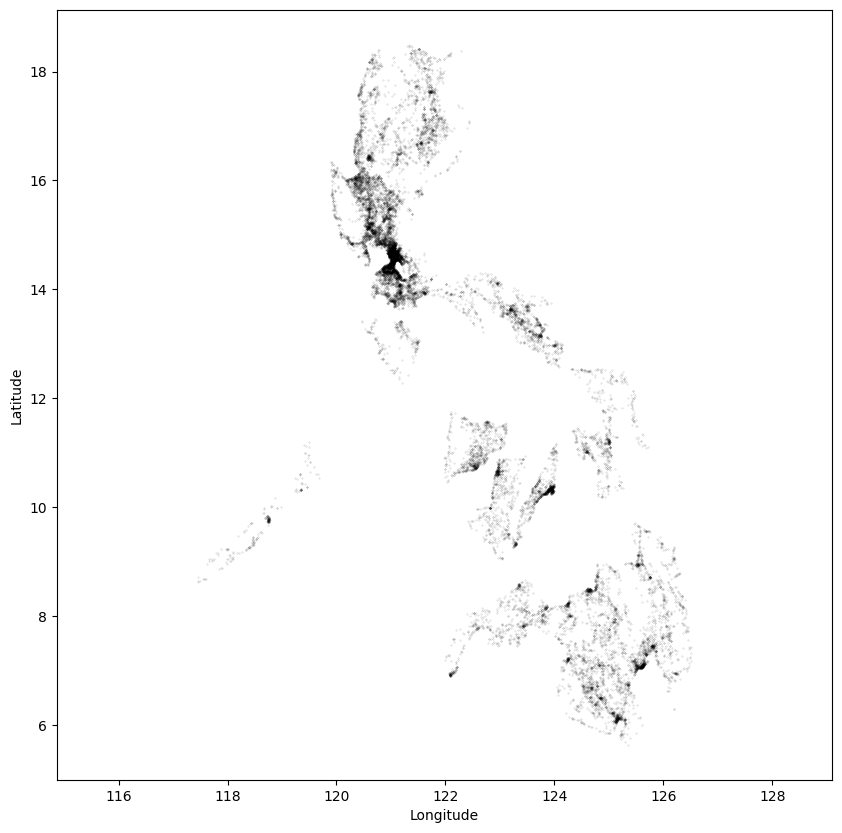

In [ ]:
#@title Visualizing the data

import matplotlib.pyplot as plt

sample_size = 20000
buildings_sample = (buildings.sample(sample_size)
                    if len(buildings) > sample_size else buildings)
plt.plot(buildings_sample.longitude, buildings_sample.latitude, 'k.',
         alpha=0.25, markersize=0.5)
plt.gcf().set_size_inches(10, 10)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axis('equal');

In [ ]:
#@title Building statistics

import numpy as np

max_grid_dimension = 1000
confidence_threshold = 0.75

buildings = buildings.query(f"confidence > {confidence_threshold}")

# Create a grid covering the dataset bounds
min_lon = buildings.longitude.min()
max_lon = buildings.longitude.max()
min_lat = buildings.latitude.min()
max_lat = buildings.latitude.max()

grid_density_degrees = (max(max_lon - min_lon, max_lat - min_lat)
                        / max_grid_dimension)

bounds = [min_lon, min_lat, max_lon, max_lat]
xcoords = np.arange(min_lon, max_lon, grid_density_degrees)
ycoords = np.arange(max_lat, min_lat, -grid_density_degrees)
xv, yv = np.meshgrid(xcoords, ycoords)
xy = np.stack([xv.ravel(), yv.ravel()]).transpose()

print(f"Calculated grid of size {xv.shape[0]} x {xv.shape[1]}.")

geotransform = (min_lon, grid_density_degrees, 0,
                max_lat, 0, -grid_density_degrees)

def lonlat_to_xy(lon, lat, geotransform):
    x = int((lon - geotransform[0])/geotransform[1])
    y = int((lat - geotransform[3])/geotransform[5])
    return x,y

counts = np.zeros(xv.shape)
area_totals = np.zeros(xv.shape)

for lat, lon, area in tqdm.notebook.tqdm(
    zip(buildings.latitude, buildings.longitude, buildings.area_in_meters)):
  x, y = lonlat_to_xy(lon, lat, geotransform)
  if x >= 0 and y >= 0 and x < len(xcoords) and y < len(ycoords):
    counts[y, x] += 1
    area_totals[y, x] += area

area_totals[counts == 0] = np.nan
counts[counts == 0] = np.nan
mean_area = area_totals / counts

Calculated grid of size 1001 x 724.


0it [00:00, ?it/s]

/tmp/ipykernel_6153/3895724325.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([f'{x:.0f}' for x in 10 ** cbar.ax.get_yticks()])


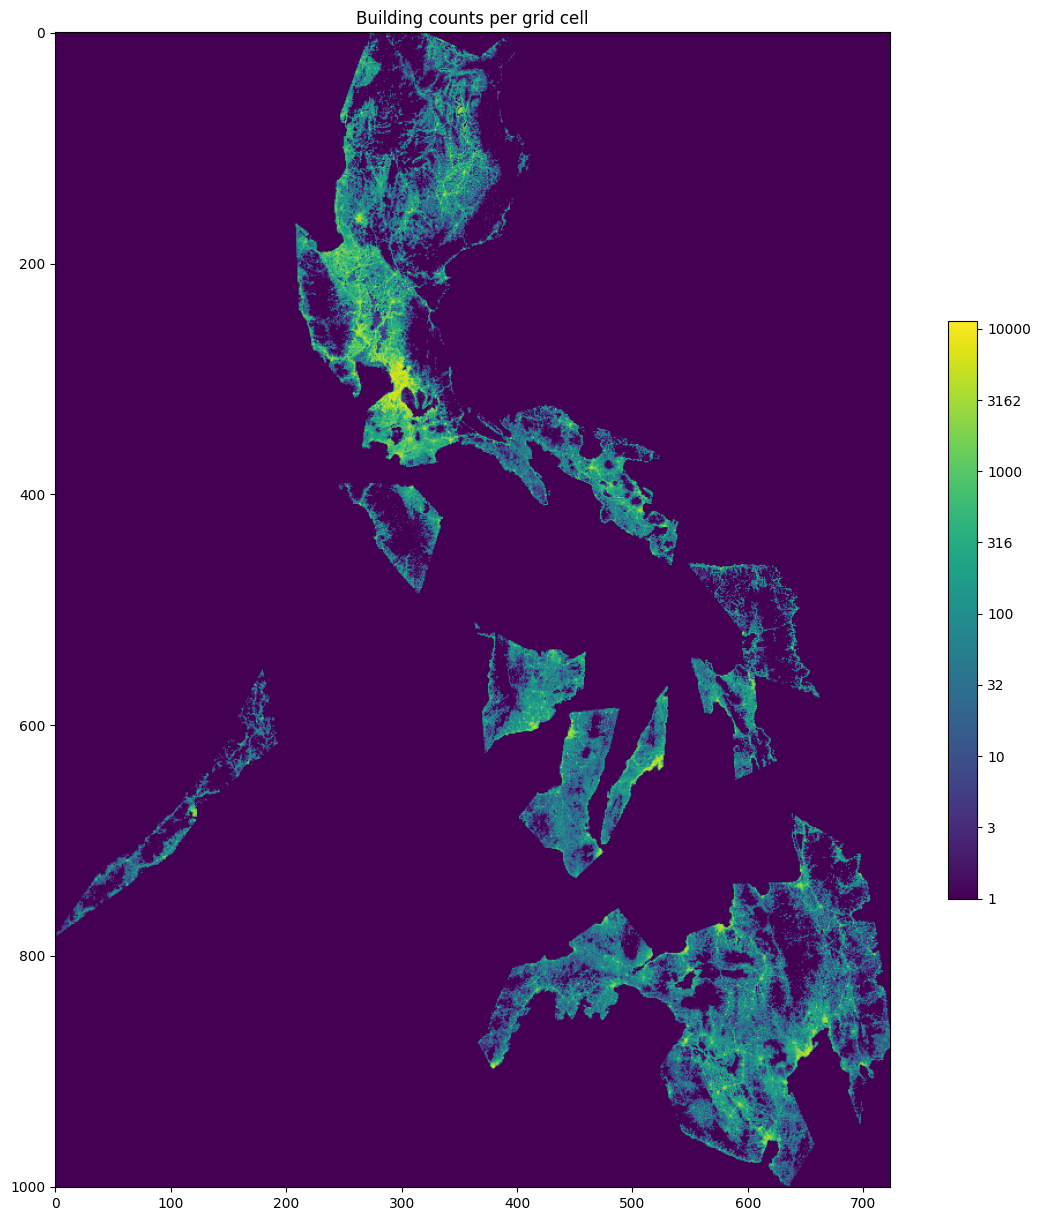

In [ ]:
plt.imshow(np.log10(np.nan_to_num(counts) + 1.), cmap="viridis")
plt.gcf().set_size_inches(15, 15)
cbar = plt.colorbar(shrink=0.5)
cbar.ax.set_yticklabels([f'{x:.0f}' for x in 10 ** cbar.ax.get_yticks()])
plt.title("Building counts per grid cell");

In [ ]:
from osgeo import gdal
from google.colab import files

def save_geotiff(filename, values, geotransform):
  driver = gdal.GetDriverByName("GTiff")
  dataset = driver.Create(filename, values.shape[1], values.shape[0], 1,
                          gdal.GDT_Float32)
  dataset.SetGeoTransform(geotransform)
  band = dataset.GetRasterBand(1)
  band.WriteArray(values)
  band.SetNoDataValue(-1)
  dataset.FlushCache()

filename = "building_counts.tiff"
save_geotiff(filename, counts, geotransform)
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

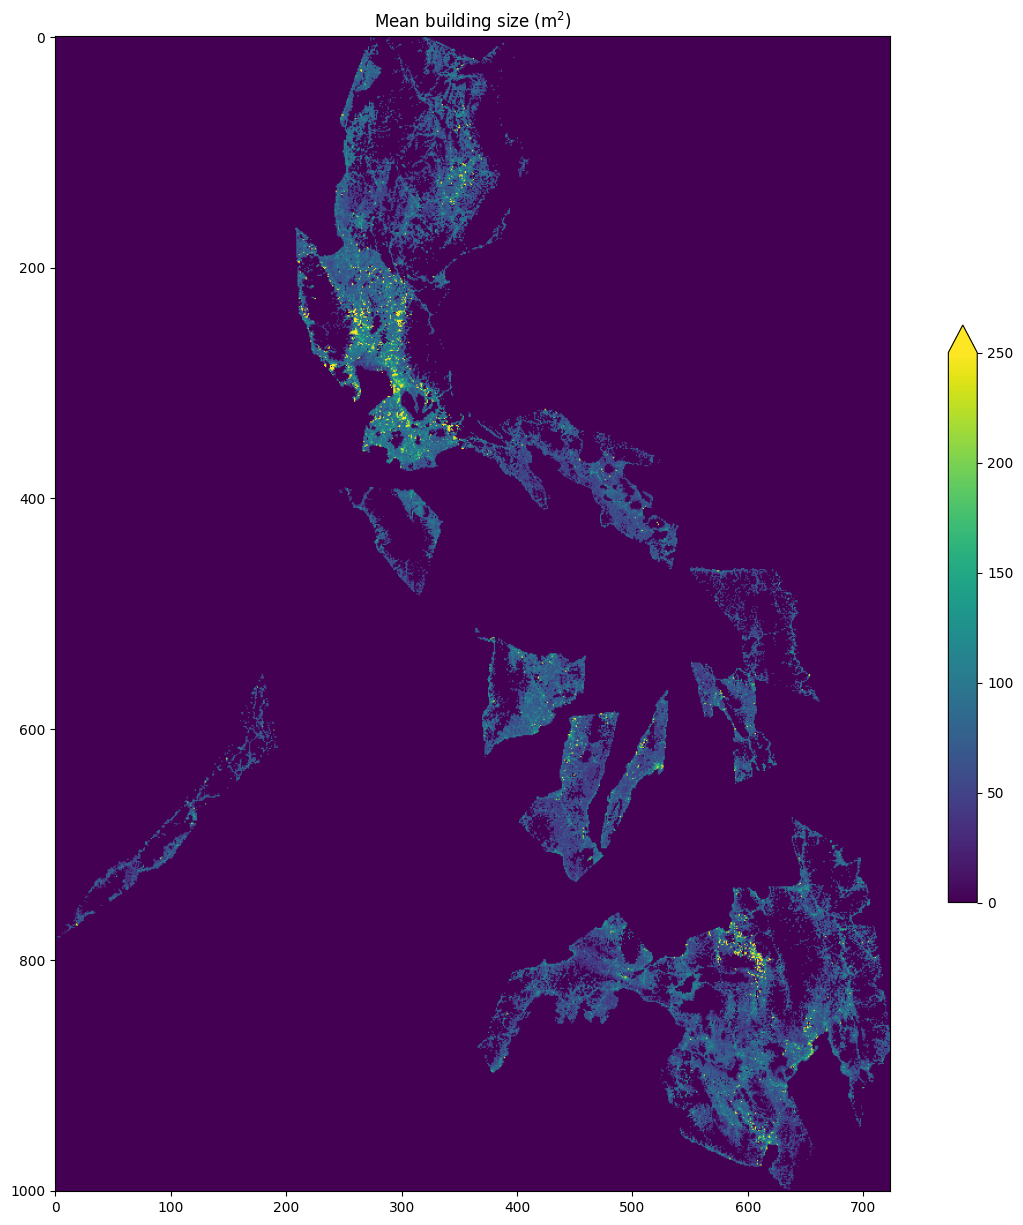

In [ ]:
# Only calculate the mean building size for grid locations with at
# least a few buildings, so that we get more reliable averages.
mean_area_filtered = mean_area.copy()
mean_area_filtered[counts < 10] = 0

# Set a maximum value for the colour scale, to make the plot brighter.
plt.imshow(np.nan_to_num(mean_area_filtered), vmax=250, cmap="viridis")
plt.title("Mean building size (m$^2$)")
plt.colorbar(shrink=0.5, extend="max")
plt.gcf().set_size_inches(15, 15)

filename = "mean_building_size.tiff"
save_geotiff(filename, counts, geotransform)
files.download(filename)